# Sistemas de Recomendación con MovieLens 100k
Este notebook guía al alumno en la implementación, entrenamiento, evaluación y visualización de modelos de recomendación clásicos usando la colección MovieLens 100k.

**Secciones:**
1. Carga de datos y preprocesamiento
2. Visualización del histórico de un usuario
3. Implementación de modelos de recomendación
4. Entrenamiento y evaluación de modelos
5. Visualización de resultados y recomendaciones
6. Interacción: actualización del perfil del usuario
7. Cálculo de métricas de error
8. Esqueleto para métricas de ranking

## 1. Carga de datos y preprocesamiento
En esta sección se cargan los datos de la colección MovieLens 100k, incluyendo los splits base-test, títulos, descripciones y URLs de IMDb. Se realiza el preprocesamiento necesario para su uso en los modelos de recomendación.

In [1]:
# Importar librerías necesarias
%pip install pandas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, Image
import os
import urllib
from collections import defaultdict

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [2]:
# Definir rutas de los archivos
DATA_DIR = './assignment/ml-100k/'
RATINGS_FILE = os.path.join(DATA_DIR, 'u.data')
ITEMS_FILE = os.path.join(DATA_DIR, 'u.item')
USERS_FILE = os.path.join(DATA_DIR, 'u.user')
BASE_FILE = os.path.join(DATA_DIR, 'base/u1.base')
TEST_FILE = os.path.join(DATA_DIR, 'test/u1.test')
ITEMS_TSV = os.path.join(DATA_DIR, 'categories/items.tsv')
DESCRIPTIONS_DIR = os.path.join(DATA_DIR, 'descriptions/')

In [3]:
# Cargar ratings base y test
ratings_base = pd.read_csv(BASE_FILE, sep=',', names=['user_id', 'item_id', 'rating', 'timestamp'])
ratings_test = pd.read_csv(TEST_FILE, sep=',', names=['user_id', 'item_id', 'rating', 'timestamp'])
print('Ratings base:', ratings_base.shape)
print('Ratings test:', ratings_test.shape)

Ratings base: (80000, 4)
Ratings test: (20000, 4)


In [4]:
# Cargar información de películas (títulos, url imdb, etc.)
items = pd.read_csv(ITEMS_FILE, sep='|', encoding='latin-1', header=None,
                    names=['item_id','title','release_date','video_release_date','imdb_url','unknown','Action','Adventure','Animation','Children','Comedy','Crime','Documentary','Drama','Fantasy','Film-Noir','Horror','Musical','Mystery','Romance','Sci-Fi','Thriller','War','Western'])
items = items.set_index('item_id')
items.head()

,title,release_date,video_release_date,imdb_url,unknown,Action,Adventure,Animation,Children,Comedy,...,Fantasy,Film-Noir,Horror,Musical,Mystery,Romance,Sci-Fi,Thriller,War,Western
item_id,,,,,,,,,,,,,,,,,,,,,
1,Toy Story (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?Toy%20Story%2...,0,0,0,1,1,1,...,0,0,0,0,0,0,0,0,0,0
2,GoldenEye (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?GoldenEye%20(...,0,1,1,0,0,0,...,0,0,0,0,0,0,0,1,0,0
3,Four Rooms (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?Four%20Rooms%...,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
4,Get Shorty (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?Get%20Shorty%...,0,1,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
5,Copycat (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?Copycat%20(1995),0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0


In [5]:
# Cargar descripciones de películas (si existen)
def load_descriptions(descriptions_dir):
    descriptions = {}
    for fname in os.listdir(descriptions_dir):
        try:
            with open(os.path.join(descriptions_dir, fname), 'r', encoding='utf-8') as f:
                descriptions[int(fname)] = f.read()
        except Exception as e:
            pass
    return descriptions
descriptions = load_descriptions(DESCRIPTIONS_DIR)
print(f"Descripciones cargadas: {len(descriptions)}")

Descripciones cargadas: 1678


## 2. Visualización del histórico de un usuario
Selecciona un usuario y visualiza su histórico de películas vistas y valoraciones.

In [6]:
# Función para visualizar el histórico de un usuario
def mostrar_historico_usuario(user_id, ratings_df, items_df):
    user_ratings = ratings_df[ratings_df['user_id'] == user_id]
    merged = user_ratings.merge(items_df, left_on='item_id', right_index=True)
    display(merged[['title', 'rating', 'imdb_url']])
    plt.figure(figsize=(10,4))
    plt.hist(user_ratings['rating'], bins=np.arange(0.5,6.5,1), rwidth=0.8)
    plt.title(f'Histórico de ratings del usuario {user_id}')
    plt.xlabel('Rating')
    plt.ylabel('Frecuencia')
    plt.show()

,title,rating,imdb_url
217,Muppet Treasure Island (1996),3,http://us.imdb.com/M/title-exact?Muppet%20Trea...
218,"Birdcage, The (1996)",3,"http://us.imdb.com/M/title-exact?Birdcage,%20T..."
219,Batman Forever (1995),4,http://us.imdb.com/M/title-exact?Batman%20Fore...
220,Star Wars (1977),4,http://us.imdb.com/M/title-exact?Star%20Wars%2...
221,"Santa Clause, The (1994)",1,http://us.imdb.com/M/title-exact?Santa%20Claus...
...,...,...,...
303,Star Trek V: The Final Frontier (1989),1,http://us.imdb.com/M/title-exact?Star%20Trek%2...
304,Grease (1978),1,http://us.imdb.com/M/title-exact?Grease%20(1978)
305,Jaws 2 (1978),1,http://us.imdb.com/M/title-exact?Jaws%202%20(1...
306,Jackie Chan's First Strike (1996),4,http://us.imdb.com/M/title-exact?Police%20Stor...


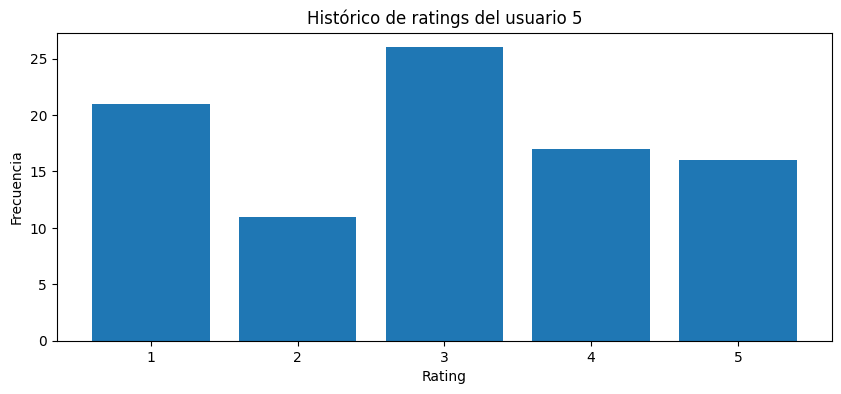

In [7]:
# Ejemplo de visualización para un usuario
usuario_ejemplo = 5
mostrar_historico_usuario(usuario_ejemplo, ratings_base, items)

## 3. Implementación de modelos de recomendación
En esta sección se implementan los modelos clásicos de recomendación: popularidad, KNN usuario, KNN ítem y filtrado colaborativo simple.

In [8]:
# Modelo de Popularidad
class PopularidadRecommender:
    def fit(self, ratings):
        self.popular_items = ratings.groupby('item_id')['rating'].mean().sort_values(ascending=False)
    def recommend(self, user_id, ratings, n=10):
        vistos = set(ratings[ratings['user_id'] == user_id]['item_id'])
        recomendaciones = [item for item in self.popular_items.index if item not in vistos][:n]
        return recomendaciones

In [9]:
# Modelo KNN Usuario (con precompute de vecinos)
class KNNUsuarioRecommender:
    def __init__(self, n=5):
        self.n = n
        self.ratings = None
        self.precomputed_neighbors = None
    def fit(self, ratings):
        self.ratings = ratings
        self.precomputed_neighbors = None
    def precompute(self):
        self.precomputed_neighbors = {}
        user_ids = self.ratings['user_id'].unique()
        user_items_map = {uid: set(self.ratings[self.ratings['user_id'] == uid]['item_id']) for uid in user_ids}
        for user_id in user_ids:
            similarities = {}
            user_items = user_items_map[user_id]
            for other_id in user_ids:
                if other_id == user_id: continue
                other_items = user_items_map[other_id]
                sim = len(user_items & other_items) / (len(user_items | other_items) + 1e-9)
                similarities[other_id] = sim
            top_users = sorted(similarities, key=similarities.get, reverse=True)[:self.n]
            self.precomputed_neighbors[user_id] = [(uid, similarities[uid]) for uid in top_users]
    def recommend(self, user_id):
        if self.precomputed_neighbors is None:
            self.precompute()
        user_items = set(self.ratings[self.ratings['user_id'] == user_id]['item_id'])
        neighbors = self.precomputed_neighbors.get(user_id, [])
        recs = set()
        for uid, _ in neighbors:
            recs |= set(self.ratings[self.ratings['user_id'] == uid]['item_id'])
        recs -= user_items
        return list(recs)[:self.n]
    def predict(self, user_id, item_id):
        if self.precomputed_neighbors is None:
            self.precompute()
        neighbors = self.precomputed_neighbors.get(user_id, [])
        ratings_sim = []
        for other_id, sim in neighbors:
            rating = self.ratings[(self.ratings['user_id'] == other_id) & (self.ratings['item_id'] == item_id)]['rating']
            if not rating.empty:
                ratings_sim.append((sim, rating.values[0]))
        if ratings_sim:
            num = sum(sim * r for sim, r in ratings_sim)
            denom = sum(sim for sim, _ in ratings_sim)
            return num / denom if denom > 0 else self.ratings['rating'].mean()
        else:
            return self.ratings['rating'].mean()

In [10]:
# Modelo KNN Ítem (con precompute de vecinos)
class KNNItemRecommender:
    def __init__(self, n=5):
        self.n = n
        self.ratings = None
        self.precomputed_neighbors = None
    def fit(self, ratings):
        self.ratings = ratings
        self.precomputed_neighbors = None
    def precompute(self):
        self.precomputed_neighbors = {}
        item_ids = self.ratings['item_id'].unique()
        item_users_map = {iid: set(self.ratings[self.ratings['item_id'] == iid]['user_id']) for iid in item_ids}
        for item_id in item_ids:
            similarities = {}
            target_users = item_users_map[item_id]
            for other_item in item_ids:
                if other_item == item_id: continue
                other_users = item_users_map[other_item]
                sim = len(target_users & other_users) / (len(target_users | other_users) + 1e-9)
                similarities[other_item] = sim
            top_items = sorted(similarities, key=similarities.get, reverse=True)[:self.n]
            self.precomputed_neighbors[item_id] = [(iid, similarities[iid]) for iid in top_items]
    def recommend(self, user_id):
        if self.precomputed_neighbors is None:
            self.precompute()
        user_items = set(self.ratings[self.ratings['user_id'] == user_id]['item_id'])
        similarities = defaultdict(float)
        for item in user_items:
            neighbors = self.precomputed_neighbors.get(item, [])
            for other_item, sim in neighbors:
                if other_item in user_items: continue
                similarities[other_item] += sim
        recs = sorted(similarities, key=similarities.get, reverse=True)[:self.n]
        return recs
    def predict(self, user_id, item_id):
        if self.precomputed_neighbors is None:
            self.precompute()
        user_items = set(self.ratings[self.ratings['user_id'] == user_id]['item_id'])
        neighbors = self.precomputed_neighbors.get(item_id, [])
        ratings_sim = []
        for other_item, sim in neighbors:
            rating = self.ratings[(self.ratings['user_id'] == user_id) & (self.ratings['item_id'] == other_item)]['rating']
            if not rating.empty:
                ratings_sim.append((sim, rating.values[0]))
        if ratings_sim:
            num = sum(sim * r for sim, r in ratings_sim)
            denom = sum(sim for sim, _ in ratings_sim)
            return num / denom if denom > 0 else self.ratings['rating'].mean()
        else:
            return self.ratings['rating'].mean()

In [11]:
# Filtrado colaborativo simple (media de ratings por usuario e ítem)
class SimpleCFRecommender:
    def fit(self, ratings):
        self.global_mean = ratings['rating'].mean()
        self.user_means = ratings.groupby('user_id')['rating'].mean()
        self.item_means = ratings.groupby('item_id')['rating'].mean()
    def predict(self, user_id, item_id):
        user_mean = self.user_means.get(user_id, self.global_mean)
        item_mean = self.item_means.get(item_id, self.global_mean)
        return (user_mean + item_mean) / 2
    def recommend(self, user_id, ratings, n=10):
        vistos = set(ratings[ratings['user_id'] == user_id]['item_id'])
        candidates = [item for item in self.item_means.index if item not in vistos]
        scores = [(item, self.predict(user_id, item)) for item in candidates]
        scores.sort(key=lambda x: x[1], reverse=True)
        return [item for item, score in scores[:n]]

## 4. Entrenamiento y evaluación de modelos
Entrena los modelos implementados y evalúa su desempeño usando los splits base-test.

In [12]:
# Entrenar y evaluar modelos
pop_model = PopularidadRecommender()
pop_model.fit(ratings_base)
knn_user_model = KNNUsuarioRecommender()
knn_user_model.fit(ratings_base)
knn_item_model = KNNItemRecommender()
knn_item_model.fit(ratings_base)
cf_model = SimpleCFRecommender()
cf_model.fit(ratings_base)

## 5. Visualización de Resultados y Recomendaciones
Muestra gráficamente las recomendaciones generadas por un modelo para un usuario, incluyendo el histórico y las nuevas sugerencias. Permite ver carátulas usando la OMDb API.

In [13]:
# Función para mostrar recomendaciones y carátulas usando OMDb API, leyendo imdb_id del archivo id_imdb_id
def cargar_id_imdb_id(path):
    id_map = {}
    with open(path, 'r', encoding='utf-8') as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) == 2:
                item_id, imdb_id = parts
                id_map[int(item_id)] = imdb_id
    return id_map
ID_IMDB_FILE = os.path.join(DATA_DIR, 'id_imdb_id')
itemid_to_imdbid = cargar_id_imdb_id(ID_IMDB_FILE)

def obtener_poster_omdb(imdb_id, api_key='YOUR_OMDB_API_KEY'):
    url = f'https://www.omdbapi.com/?i={imdb_id}&apikey={api_key}'
    try:
        with urllib.request.urlopen(url) as response:
            data = response.read().decode('utf-8')
            import json
            data = json.loads(data)
            poster_url = data.get('Poster', None)
            return poster_url
    except Exception as e:
        print(f'Error OMDb: {e}')
    return None

def mostrar_recomendaciones(user_id, model, ratings_df, items_df, n=5, api_key='58c7a120'):
    recs = model.recommend(user_id, ratings_df, n) if hasattr(model, 'recommend') else model.recommend(user_id, n)
    recs_info = items_df.loc[recs][['title']].copy()
    recs_info['imdb_id'] = [itemid_to_imdbid.get(item, None) for item in recs]
    display(recs_info)
    for pos, (idx, row) in enumerate(recs_info.iterrows(), 1):
        imdb_id = row['imdb_id']
        print(f"{pos}. {row['title']}")
        if imdb_id:
            poster_url = obtener_poster_omdb(imdb_id, api_key)
            if poster_url:
                display(Image(url=poster_url, width=120, height=180))

In [14]:
# Ejemplo de visualización de recomendaciones para un usuario y modelo
mostrar_recomendaciones(usuario_ejemplo, pop_model, ratings_base, items, n=5)

,title,imdb_id
item_id,,
1189,Prefontaine (1997),tt0119937
1653,Entertaining Angels: The Dorothy Day Story (1996),tt0116212
1599,Someone Else's America (1995),tt0114494
1500,Santa with Muscles (1996),tt0117550
1467,"Saint of Fort Washington, The (1993)",tt0108026


1. Prefontaine (1997)


2. Entertaining Angels: The Dorothy Day Story (1996)


3. Someone Else's America (1995)


4. Santa with Muscles (1996)


5. Saint of Fort Washington, The (1993)


## 6. Interacción: Actualización del perfil del usuario
Permite al alumno seleccionar una recomendación, asignar una valoración y actualizar el perfil del usuario. Muestra cómo cambian las recomendaciones tras la actualización.

In [15]:
# Mostrar el perfil del usuario antes de la actualización
print("Histórico de películas vistas y valoraciones del usuario antes de la actualización:")
user_ratings = ratings_base[ratings_base['user_id'] == usuario_ejemplo]
historico = user_ratings.merge(items, left_on='item_id', right_index=True)
for _, row in historico.iterrows():
    print(f"{row['title']} - Valoración: {row['rating']}")

top_recomendados = pop_model.recommend(usuario_ejemplo, ratings_base, n=3)
titulos_recomendados = [items.loc[item_id]['title'] for item_id in top_recomendados]
print("\nPelículas recomendadas:")
for i, titulo in enumerate(titulos_recomendados):
    print(f"{i+1}. {titulo}")

ratings_nuevos = []
for i, item_recomendado in enumerate(top_recomendados):
    titulo_recomendado = items.loc[item_recomendado]['title']
    while True:
        try:
            rating_usuario = int(input(f"Por favor, ingresa una valoración entre 1 y 5 para '{titulo_recomendado}': "))
            if 1 <= rating_usuario <= 5:
                ratings_nuevos.append({'user_id': usuario_ejemplo, 'item_id': item_recomendado, 'rating': rating_usuario, 'timestamp': 0})
                break
            else:
                print("La valoración debe estar entre 1 y 5.")
        except ValueError:
            print("Por favor, ingresa un número entero válido.")

ratings_base_actualizado = pd.concat([ratings_base, pd.DataFrame(ratings_nuevos)], ignore_index=True)
cf_model.fit(ratings_base_actualizado)
mostrar_recomendaciones(usuario_ejemplo, cf_model, ratings_base_actualizado, items, n=5)

Histórico de películas vistas y valoraciones del usuario antes de la actualización:
Muppet Treasure Island (1996) - Valoración: 3
Birdcage, The (1996) - Valoración: 3
Batman Forever (1995) - Valoración: 4
Star Wars (1977) - Valoración: 4
Santa Clause, The (1994) - Valoración: 1
While You Were Sleeping (1995) - Valoración: 1
Four Weddings and a Funeral (1994) - Valoración: 4
Aladdin (1992) - Valoración: 4
Snow White and the Seven Dwarfs (1937) - Valoración: 3
Heavy Metal (1981) - Valoración: 5
Sgt. Bilko (1996) - Valoración: 3
Independence Day (ID4) (1996) - Valoración: 4
2001: A Space Odyssey (1968) - Valoración: 4
Lawnmower Man, The (1992) - Valoración: 1
Willy Wonka and the Chocolate Factory (1971) - Valoración: 3
On Golden Pond (1981) - Valoración: 1
Return of the Pink Panther, The (1974) - Valoración: 5
Monty Python and the Holy Grail (1974) - Valoración: 3
Wrong Trousers, The (1993) - Valoración: 5
Empire Strikes Back, The (1980) - Valoración: 5
Raiders of the Lost Ark (1981) - Va

Por favor, ingresa una valoración entre 1 y 5 para 'Prefontaine (1997)':  1
Por favor, ingresa una valoración entre 1 y 5 para 'Entertaining Angels: The Dorothy Day Story (1996)':  4
Por favor, ingresa una valoración entre 1 y 5 para 'Someone Else's America (1995)':  3


,title,imdb_id
item_id,,
1122,They Made Me a Criminal (1939),tt0032022
1201,Marlene Dietrich: Shadow and Light (1996),tt0116992
1293,Star Kid (1997),tt0120478
1467,"Saint of Fort Washington, The (1993)",tt0108026
1500,Santa with Muscles (1996),tt0117550


1. They Made Me a Criminal (1939)


2. Marlene Dietrich: Shadow and Light (1996) 


3. Star Kid (1997)


4. Saint of Fort Washington, The (1993)


5. Santa with Muscles (1996)


## 7. Cálculo de métricas de error
Implementa métricas de error como RMSE y MAE para evaluar los modelos.

In [20]:
# Métricas de error: RMSE y MAE
def calcular_rmse_mae(model, test_df):
    preds = []
    trues = []
    import concurrent.futures

    def predict_row(row):
        user_id, item_id, true_rating = row['user_id'], row['item_id'], row['rating']
        if hasattr(model, 'predict'):
            pred = model.predict(user_id, item_id)
        else:
            pred = 0
        return pred, true_rating

    with concurrent.futures.ThreadPoolExecutor() as executor:
        results = list(executor.map(predict_row, [row for _, row in test_df.iterrows()]))

    preds, trues = zip(*results)
    preds = np.array(preds)
    trues = np.array(trues)
    rmse = np.sqrt(np.mean((preds - trues)**2))
    mae = np.mean(np.abs(preds - trues))
    return rmse, mae
# Imprimir métricas de error de todos los recomendadores
for nombre, modelo in [
    ("Popularidad", pop_model),
    ("KNN Usuario", knn_user_model),
    ("KNN Ítem", knn_item_model),
    ("Filtrado Colaborativo Simple", cf_model)
]:
    rmse, mae = calcular_rmse_mae(modelo, ratings_test)
    print(f"{nombre}: RMSE={rmse:.4f}, MAE={mae:.4f}")

Popularidad: RMSE=3.7193, MAE=3.5359
KNN Usuario: RMSE=1.2051, MAE=0.9456
KNN Ítem: RMSE=1.1382, MAE=0.8653
Filtrado Colaborativo Simple: RMSE=0.9985, MAE=0.8085


## 8. Esqueleto para métricas de ranking
A continuación se proporciona un esqueleto para que los alumnos implementen métricas de ranking como Precision@k y Recall@k.

In [51]:
# Esqueleto para Precision@k y Recall@k
from pprint import pprint
pprint(dict(row))

import concurrent.futures
with concurre

def precision_at_k(recommended_items, relevant_items, k):

    
    preds, trues = zip(*results)
    pass
    
        
def recall_at_k(recommended_items, relevant_items, k):
    pass

{'Action': 1,
 'Adventure': 0,
 'Animation': 0,
 'Children': 0,
 'Comedy': 1,
 'Crime': 0,
 'Documentary': 0,
 'Drama': 0,
 'Fantasy': 0,
 'Film-Noir': 0,
 'Horror': 0,
 'Musical': 0,
 'Mystery': 0,
 'Romance': 0,
 'Sci-Fi': 0,
 'Thriller': 0,
 'War': 0,
 'Western': 0,
 'imdb_url': 'http://us.imdb.com/M/title-exact?Beverly%20Hills%20Ninja%20(1997)',
 'item_id': 456,
 'rating': 1,
 'release_date': '17-Jan-1997',
 'timestamp': 875636375,
 'title': 'Beverly Hills Ninja (1997)',
 'unknown': 0,
 'user_id': 5,
 'video_release_date': nan}


NameError: name 'predict_row' is not defined

## 9. Implementación de SLIM y FSLIM
En esta sección se implementan los modelos SLIM y FSLIM para recomendación basada en ítems. Se utilizan librerías como scikit-learn para la optimización.

In [42]:
# SLIM: Sparse Linear Methods for Top-N Recommender Systems
from sklearn.linear_model import ElasticNet
class SLIMRecommender:
    def __init__(self, l1_reg=1e-4, l2_reg=1e-4, max_iter=100):
        self.l1_reg = l1_reg
        self.l2_reg = l2_reg
        self.max_iter = max_iter
        self.W = None
        self.ratings_matrix = None

    def fit(self, ratings_matrix):
        n_items = ratings_matrix.shape[1]
        self.W = np.zeros((n_items, n_items))
        for j in range(n_items):
            target = ratings_matrix[:, j]
            X = np.delete(ratings_matrix, j, axis=1)
            model = ElasticNet(alpha=self.l1_reg + self.l2_reg, l1_ratio=self.l1_reg/(self.l1_reg + self.l2_reg), max_iter=self.max_iter, positive=True)
            model.fit(X, target)
            coefs = model.coef_
            self.W[j, :j] = coefs[:j]
            self.W[j, j+1:] = coefs[j:]
        np.fill_diagonal(self.W, 0)
        self.ratings_matrix = ratings_matrix

    def recommend(self, user_vector, n=10):
        scores = user_vector @ self.W
        return np.argsort(scores)[::-1][:n]
    def predict(self, user_id, item_id, ratings_matrix=None):
        # ratings_matrix: matriz de usuarios x items (opcional, si no se guarda en el modelo)
        # Si ratings_matrix no se pasa, no se puede predecir
        if ratings_matrix is None and self.ratings_matrix is None:
            raise ValueError("Se requiere ratings_matrix para predecir en SLIM")
        user_idx = user_id - 1  # Asume que user_id empieza en 1 y es consecutivo
        item_idx = item_id - 1  # Asume que item_id empieza en 1 y es consecutivo
        user_vector = ratings_matrix[user_idx] if ratings_matrix is not None else self.ratings_matrix[user_idx]
        score = user_vector @ self.W[:, item_idx]
        return score

In [39]:
# FSLIM: Factored SLIM (aproximación con factorización de matrices)
from sklearn.decomposition import NMF
class FSLIMRecommender:
    def __init__(self, n_factors=50, max_iter=200):
        self.n_factors = n_factors
        self.max_iter = max_iter
        self.P = None
        self.Q = None
        self.ratings_matrix = None
    def fit(self, ratings_matrix):
        nmf = NMF(n_components=self.n_factors, max_iter=self.max_iter, init='random', random_state=42)
        self.P = nmf.fit_transform(ratings_matrix)
        self.Q = nmf.components_
        self.ratings_matrix = ratings_matrix
    def recommend(self, user_vector, n=10):
        scores = self.P @ self.Q
        user_scores = scores[user_vector.nonzero()[0]].sum(axis=0)
        return np.argsort(user_scores)[::-1][:n]
    def predict(self, user_id, item_id, ratings_matrix=None):
        # ratings_matrix: matriz de usuarios x items (opcional, si no se guarda en el modelo)
        if ratings_matrix is None and self.ratings_matrix is None:
            raise ValueError("Se requiere ratings_matrix para predecir en FSLIM")
        user_idx = user_id - 1  # Asume que user_id empieza en 1 y es consecutivo
        item_idx = item_id - 1  # Asume que item_id empieza en 1 y es consecutivo
        user_factors = self.P[user_idx]
        item_factors = self.Q[:, item_idx]
        score = user_factors @ item_factors
        return score

In [40]:
from sklearn.preprocessing import MinMaxScaler
import time
from sklearn.exceptions import ConvergenceWarning
import warnings

# Escalar la matriz de ratings preservando no-negatividad
ratings_matrix = ratings_base.pivot(index='user_id', columns='item_id', values='rating').fillna(0).values
scaler = MinMaxScaler()
ratings_matrix_scaled = scaler.fit_transform(ratings_matrix)

# Opcional: silenciar warnings de convergencia (para no saturar la salida)
warnings.filterwarnings("ignore", category=ConvergenceWarning)

t0 = time.perf_counter()
slim_model = SLIMRecommender(l1_reg=1e-3, l2_reg=1e-3, max_iter=2000)
slim_model.fit(ratings_matrix_scaled)
slim_time = time.perf_counter() - t0

t1 = time.perf_counter()
fslim_model = FSLIMRecommender(n_factors=50, max_iter=500)
fslim_model.fit(ratings_matrix_scaled)
fslim_time = time.perf_counter() - t1

print(f"SLIM - tiempo de entrenamiento: {slim_time:.2f}s")
print(f"FSLIM - tiempo de entrenamiento: {fslim_time:.2f}s")


SLIM - tiempo de entrenamiento: 71.06s
FSLIM - tiempo de entrenamiento: 3.38s


In [41]:

for nombre, modelo in [
    ("Popularidad", pop_model),
    ("KNN Usuario", knn_user_model),
    ("KNN Ítem", knn_item_model),
    ("Filtrado Colaborativo Simple", cf_model),
    ("SLIM", slim_model),
    ("FSLIM", fslim_model)
]:
    rmse, mae = calcular_rmse_mae(modelo, ratings_test)
    print(f"{nombre}: RMSE={rmse:.4f}, MAE={mae:.4f}")

Popularidad: RMSE=3.7193, MAE=3.5359
KNN Usuario: RMSE=1.2051, MAE=0.9456
KNN Ítem: RMSE=1.1382, MAE=0.8653
Filtrado Colaborativo Simple: RMSE=0.9985, MAE=0.8085
SLIM: RMSE=3.5349, MAE=3.3452
FSLIM: RMSE=3.5620, MAE=3.3789
